
# Feature-wise Self-attention DeepSurv


In [ ]:
# =========================
# 1. Install / import packages
# =========================
!pip -q install lifelines pyarrow joblib

import os
import math
import json
import time
import copy
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from lifelines.utils import concordance_index


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.5 MB/s eta 0:00:00


In [ ]:
# =========================
# 2. Mount Google Drive
# =========================
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:

# =========================
# 3. Reproducibility
# =========================
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda



## Set your dataset location

Update the path below after your teammate uploads the normalized METABRIC data to your shared Google Drive folder.

Examples:
- `/content/drive/MyDrive/ECEN766/METABRIC/metabric_normalized.npz`
- `/content/drive/MyDrive/ECEN766/METABRIC/`


In [ ]:
# =========================
# 4. Data path configuration
# =========================



DATA_DIR = "/content/drive/MyDrive/ECEN766final/Processed"



# Set this to False if the parquet features are already normalized

STANDARDIZE_IN_NOTEBOOK = False



assert os.path.exists(DATA_DIR), f"Folder not found: {DATA_DIR}"
print("Found data folder:", DATA_DIR)
print("Files:", sorted(os.listdir(DATA_DIR)))


Found data folder: /content/drive/MyDrive/ECEN766final/Processed
Files: ['X_test.parquet', 'X_test2000.parquet', 'X_test500.parquet', 'X_train.parquet', 'X_train2000.parquet', 'X_train500.parquet', 'X_val.parquet', 'X_val2000.parquet', 'X_val500.parquet', 'scaler.pkl', 'scaler2000.pkl', 'scaler500.pkl', 'y_test.parquet', 'y_test2000.parquet', 'y_test500.parquet', 'y_train.parquet', 'y_train2000.parquet', 'y_train500.parquet', 'y_val.parquet', 'y_val2000.parquet', 'y_val500.parquet']


In [ ]:
# =========================
# 5. Data loading helpers
# =========================


def _to_numpy(df_or_series):
    if hasattr(df_or_series, "to_numpy"):
        arr = df_or_series.to_numpy()
    else:
        arr = np.asarray(df_or_series)
    return arr

def _flatten_if_single_column(arr):
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr[:, 0]
    return arr

def _extract_time_event(y_df):
    """
    Flexible parser for y parquet files.

    Supported cases:
    1) Two columns with recognizable names, e.g.:
       - time/survival_time/os_time/months
       - event/status/e/os_event
    2) Exactly two columns -> assumes:
       first column = time, second column = event
    """
    if not isinstance(y_df, pd.DataFrame):
        y_df = pd.DataFrame(y_df)

    cols_lower = {c.lower(): c for c in y_df.columns}

    possible_time = [
        "time", "t", "duration", "survival_time", "overall_survival_time",
        "os_time", "months", "time_to_event"
    ]
    possible_event = [
        "event", "e", "status", "censor", "censored", "os_event",
        "overall_survival_event"
    ]

    time_col = None
    event_col = None

    for name in possible_time:
        if name in cols_lower:
            time_col = cols_lower[name]
            break

    for name in possible_event:
        if name in cols_lower:
            event_col = cols_lower[name]
            break

    if time_col is not None and event_col is not None:
        t = y_df[time_col].to_numpy(dtype=np.float32)
        e = y_df[event_col].to_numpy(dtype=np.float32)
        return t, e

    if y_df.shape[1] == 2:
        t = y_df.iloc[:, 0].to_numpy(dtype=np.float32)
        e = y_df.iloc[:, 1].to_numpy(dtype=np.float32)
        print("[Info] y parquet has 2 columns; assuming first=time, second=event.")
        return t, e

    raise ValueError(
        "Could not infer time/event columns from y parquet. "
        f"Found columns: {list(y_df.columns)}"
    )

def load_survival_data_from_parquet(data_dir: str):
    required = [
        "X_train500.parquet", "X_val500.parquet", "X_test500.parquet",
        "y_train500.parquet", "y_val500.parquet", "y_test500.parquet",
    ]
    for fname in required:
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Missing required file: {fpath}")

    X_train_df = pd.read_parquet(os.path.join(data_dir, "X_train500.parquet"))
    X_val_df   = pd.read_parquet(os.path.join(data_dir, "X_val500.parquet"))
    X_test_df  = pd.read_parquet(os.path.join(data_dir, "X_test500.parquet"))

    y_train_df = pd.read_parquet(os.path.join(data_dir, "y_train500.parquet"))
    y_val_df   = pd.read_parquet(os.path.join(data_dir, "y_val500.parquet"))
    y_test_df  = pd.read_parquet(os.path.join(data_dir, "y_test500.parquet"))

    t_train, e_train = _extract_time_event(y_train_df)
    t_val,   e_val   = _extract_time_event(y_val_df)
    t_test,  e_test  = _extract_time_event(y_test_df)

    train_data = {
        "x": _to_numpy(X_train_df).astype(np.float32),
        "t": t_train.astype(np.float32),
        "e": e_train.astype(np.float32),
    }
    val_data = {
        "x": _to_numpy(X_val_df).astype(np.float32),
        "t": t_val.astype(np.float32),
        "e": e_val.astype(np.float32),
    }
    test_data = {
        "x": _to_numpy(X_test_df).astype(np.float32),
        "t": t_test.astype(np.float32),
        "e": e_test.astype(np.float32),
    }

    feature_names = list(X_train_df.columns)

    return train_data, val_data, test_data, feature_names


In [ ]:
# =========================
# 6. Load the parquet data
# =========================
train_data, val_data, test_data, feature_names = load_survival_data_from_parquet(DATA_DIR)

print("Train X shape:", train_data["x"].shape)
print("Val   X shape:", val_data["x"].shape)
print("Test  X shape:", test_data["x"].shape)

print("Train events:", int(np.sum(train_data["e"])))
print("Val events:", int(np.sum(val_data["e"])))
print("Test events:", int(np.sum(test_data["e"])))

print("Number of features:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

print("\nSample y_train preview:")
display(pd.read_parquet(os.path.join(DATA_DIR, "y_train.parquet")).head())


Train X shape: (1386, 500)
Val   X shape: (297, 500)
Test  X shape: (297, 500)
Train events: 799
Val events: 172
Test events: 171
Number of features: 500
First 10 feature names: ['CTXN1', 'POFUT1', 'MRPL24', 'IDO1', 'CMIP', 'TUBGCP5', 'CLN8', 'SLC25A19', 'C5orf4', 'ZNF350']

Sample y_train preview:


Hugo_Symbol,time,event
MB-4849,45.333333,1
MB-0108,42.700000,1
MB-5157,18.233333,1
MB-0605,114.600000,0
MB-6122,260.200000,0


In [ ]:
%whos

Variable                          Type                 Data/Info
----------------------------------------------------------------
AttentionBlock                    type                 <class '__main__.AttentionBlock'>
AttentionDeepSurv                 type                 <class '__main__.AttentionDeepSurv'>
DATA_DIR                          str                  /content/drive/MyDrive/ECEN766final/Processed
DEVICE                            str                  cuda
DROPOUT                           float                0.4
D_MODEL                           int                  8
FeatureEmbedding                  type                 <class '__main__.FeatureEmbedding'>
GRADIENT_CLIP                     float                1.0
HIDDEN_LAYERS                     tuple                n=1
LEARNING_RATE                     float                0.0005
N_ATTN_LAYERS                     int                  1
N_EPOCHS                          int                  150
N_FEATURES               

In [ ]:
# Debug non-finite values in loaded x arrays
for split_name, data_dict in [("train", train_data), ("val", val_data), ("test", test_data)]:
    x = data_dict["x"]
    t = data_dict["t"]
    e = data_dict["e"]

    n_nan = np.isnan(x).sum()
    n_posinf = np.isposinf(x).sum()
    n_neginf = np.isneginf(x).sum()
    total_bad = n_nan + n_posinf + n_neginf

    print(f"{split_name}:")
    print(f"  x shape      = {x.shape}")
    print(f"  NaN count    = {n_nan}")
    print(f"  +inf count   = {n_posinf}")
    print(f"  -inf count   = {n_neginf}")
    print(f"  total bad    = {total_bad}")

    if total_bad > 0:
        bad_rows = np.where(~np.isfinite(x).all(axis=1))[0]
        bad_cols = np.where(~np.isfinite(x).all(axis=0))[0]

        print(f"  bad row indices (first 20): {bad_rows[:20]}")
        print(f"  bad col indices (first 20): {bad_cols[:20]}")

    print()

train:
  x shape      = (1386, 500)
  NaN count    = 10
  +inf count   = 0
  -inf count   = 0
  total bad    = 10
  bad row indices (first 20): [ 196  245  440  445  574  679  680  681  734 1269]
  bad col indices (first 20): [0 1 2 3 4 5 6 7]

val:
  x shape      = (297, 500)
  NaN count    = 1
  +inf count   = 0
  -inf count   = 0
  total bad    = 1
  bad row indices (first 20): [148]
  bad col indices (first 20): [4]

test:
  x shape      = (297, 500)
  NaN count    = 2
  +inf count   = 0
  -inf count   = 0
  total bad    = 2
  bad row indices (first 20): [124 232]
  bad col indices (first 20): [1 7]



In [ ]:
def impute_with_train_medians(train_data, val_data, test_data):
    x_train = train_data["x"].copy()
    x_val = val_data["x"].copy()
    x_test = test_data["x"].copy()

    print("Bad values before imputation:")
    print("  train:", np.isnan(x_train).sum())
    print("  val:  ", np.isnan(x_val).sum())
    print("  test: ", np.isnan(x_test).sum())

    # Compute medians from training set only
    train_medians = np.nanmedian(x_train, axis=0)

    # If a whole training column were NaN, fallback to 0.0
    train_medians = np.where(np.isfinite(train_medians), train_medians, 0.0)

    def fill_nan_with_reference_medians(x, medians):
        inds = np.where(np.isnan(x))
        if len(inds[0]) > 0:
            x[inds] = np.take(medians, inds[1])
        return x

    x_train = fill_nan_with_reference_medians(x_train, train_medians)
    x_val = fill_nan_with_reference_medians(x_val, train_medians)
    x_test = fill_nan_with_reference_medians(x_test, train_medians)

    train_data = train_data.copy()
    val_data = val_data.copy()
    test_data = test_data.copy()

    train_data["x"] = x_train
    val_data["x"] = x_val
    test_data["x"] = x_test

    print("\nBad values after imputation:")
    print("  train:", np.isnan(train_data["x"]).sum())
    print("  val:  ", np.isnan(val_data["x"]).sum())
    print("  test: ", np.isnan(test_data["x"]).sum())

    return train_data, val_data, test_data


train_data, val_data, test_data = impute_with_train_medians(train_data, val_data, test_data)

Bad values before imputation:
  train: 10
  val:   1
  test:  2

Bad values after imputation:
  train: 0
  val:   0
  test:  0


In [ ]:

# =========================
# 7. Sanity checks
# =========================
def check_data_dict(data_dict, name="data"):
    x, t, e = data_dict["x"], data_dict["t"], data_dict["e"]
    assert len(x) == len(t) == len(e), f"{name}: mismatched lengths"
    assert np.isfinite(x).all(), f"{name}: x has non-finite values"
    assert np.isfinite(t).all(), f"{name}: t has non-finite values"
    assert np.isfinite(e).all(), f"{name}: e has non-finite values"
    assert set(np.unique(e)).issubset({0.0, 1.0}), f"{name}: e must contain only 0/1"
    assert np.all(t >= 0), f"{name}: survival times must be non-negative"

check_data_dict(train_data, "train")
check_data_dict(val_data, "val")
if test_data is not None:
    check_data_dict(test_data, "test")

print("All data checks passed.")


All data checks passed.


In [ ]:

# =========================
# 8. Standardization helper
# =========================
class Standardizer:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, x: torch.Tensor):
        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True).clamp_min(1e-8)

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        return (x - self.mean) / self.std


In [ ]:

# =========================
# 9. Sorting helper
# =========================
def sort_by_time_desc(x: torch.Tensor, t: torch.Tensor, e: torch.Tensor):
    idx = torch.argsort(t, descending=True)
    return x[idx], t[idx], e[idx]


In [ ]:

# =================================
# 10. Attention DeepSurv model
# =================================
class FeatureEmbedding(nn.Module):
    """
    Convert tabular input x of shape [B, P] into token embeddings [B, P, D].
    Each scalar feature gets its own learnable embedding vector.
    """
    def __init__(self, n_features: int, d_model: int):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, P] / output: [B, P, D]
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


class AttentionBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1, ff_mult: int = 2):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        x_norm = self.norm1(x)
        attn_out, attn_weights = self.attn(
            x_norm, x_norm, x_norm,
            need_weights=True,
            average_attn_weights=False
        )
        x = x + self.dropout(attn_out)

        x_norm = self.norm2(x)
        ff_out = self.ff(x_norm)
        x = x + self.dropout(ff_out)

        return x, attn_weights


class AttentionDeepSurv(nn.Module):
    def __init__(
        self,
        n_in: int,
        d_model: int = 32,
        n_heads: int = 4,
        n_attn_layers: int = 2,
        hidden_layers_sizes=(64, 32),
        dropout: float = 0.3,
        use_feature_pooling: bool = True,
    ):
        super().__init__()

        self.n_in = n_in
        self.d_model = d_model
        self.use_feature_pooling = use_feature_pooling

        self.feature_embed = FeatureEmbedding(n_in, d_model)

        self.attn_blocks = nn.ModuleList([
            AttentionBlock(d_model=d_model, n_heads=n_heads, dropout=dropout)
            for _ in range(n_attn_layers)
        ])

        if use_feature_pooling:
            mlp_input_dim = d_model
        else:
            mlp_input_dim = n_in * d_model

        mlp_layers = []
        in_dim = mlp_input_dim
        for h in hidden_layers_sizes:
            mlp_layers.append(nn.Linear(in_dim, h))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(dropout))
            in_dim = h

        mlp_layers.append(nn.Linear(in_dim, 1))
        self.risk_head = nn.Sequential(*mlp_layers)

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        # x: [B, P]
        z = self.feature_embed(x) # [B, P, D]

        attn_maps = []
        for block in self.attn_blocks:
            z, attn_w = block(z)
            attn_maps.append(attn_w)

        if self.use_feature_pooling:
            # Mean pooling over features -> [B, D]
            patient_repr = z.mean(dim=1)
        else:
            # Flatten all feature tokens -> [B, P*D]
            patient_repr = z.reshape(z.size(0), -1)

        log_risk = self.risk_head(patient_repr).squeeze(-1)

        if return_attention:
            return log_risk, attn_maps
        return log_risk


## Cox loss

This is a **baseline DeepSurv-style Cox partial likelihood loss** that assumes the batch is sorted by decreasing survival time.

Note: this is the simple repo-faithful baseline and does **not explicitly handle tied event times** with Breslow/Efron corrections.


In [ ]:

# =========================
# 11. Cox partial likelihood loss
# =========================
def cox_ph_loss(log_hz: torch.Tensor, event: torch.Tensor) -> torch.Tensor:
    log_hz = log_hz.reshape(-1)
    event = event.reshape(-1).float()

    log_cum_risk = torch.logcumsumexp(log_hz, dim=0)
    losses = event * (log_cum_risk - log_hz)

    n_events = event.sum().clamp_min(1.0)
    return losses.sum() / n_events


In [ ]:

# =========================
# 12. Utility: c-index evaluation
# =========================
def evaluate_cindex(model, data, scaler=None, device="cpu"):
    model.eval()

    x = torch.tensor(data["x"], dtype=torch.float32, device=device)
    t = torch.tensor(data["t"], dtype=torch.float32, device=device)
    e = torch.tensor(data["e"], dtype=torch.float32, device=device)

    if scaler is not None:
        x = scaler.transform(x)

    with torch.no_grad():
        pred = model(x).detach().cpu().numpy()

    return concordance_index(
        t.detach().cpu().numpy(),
        -pred,  # higher risk should correspond to shorter survival
        e.detach().cpu().numpy()
    )


In [ ]:

# =========================
# 13. Training loop
# =========================
def train_deepsurv(
    model,
    train_data,
    valid_data,
    n_epochs=150,
    learning_rate=5e-4,
    weight_decay=1e-4,
    standardize=True,
    device="cpu",
    verbose_every=25,
    gradient_clip=1.0,
    early_stopping_patience=15,
):
    model.to(device)


    # Prepare training tensors
    x_train = torch.tensor(train_data["x"], dtype=torch.float32, device=device)
    t_train = torch.tensor(train_data["t"], dtype=torch.float32, device=device)
    e_train = torch.tensor(train_data["e"], dtype=torch.float32, device=device)

    scaler = None
    if standardize:
        scaler = Standardizer()
        scaler.fit(x_train)
        x_train = scaler.transform(x_train)

    # Cox loss assumes data sorted by descending survival time
    x_train, t_train, e_train = sort_by_time_desc(x_train, t_train, e_train)


    # Prepare validation tensors
    x_val = t_val = e_val = None
    if valid_data is not None:
        x_val = torch.tensor(valid_data["x"], dtype=torch.float32, device=device)
        t_val = torch.tensor(valid_data["t"], dtype=torch.float32, device=device)
        e_val = torch.tensor(valid_data["e"], dtype=torch.float32, device=device)

        if scaler is not None:
            x_val = scaler.transform(x_val)

        x_val, t_val, e_val = sort_by_time_desc(x_val, t_val, e_val)


    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = []


    # Early stopping setup
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    # Runtime tracking
    total_start_time = time.time()

    for epoch in range(1, n_epochs + 1):
        epoch_start_time = time.time()


        # Train
        model.train()
        optimizer.zero_grad()

        log_hz_train = model(x_train)
        train_loss = cox_ph_loss(log_hz_train, e_train)

        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip)
        optimizer.step()


        # Evaluate on training set
        model.eval()
        with torch.no_grad():
            train_pred = model(x_train).detach().cpu().numpy()
            train_ci = concordance_index(
                t_train.detach().cpu().numpy(),
                -train_pred,
                e_train.detach().cpu().numpy()
            )

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss.item()),
            "train_cindex": float(train_ci),
            "lr": float(optimizer.param_groups[0]["lr"]),
        }


        # Evaluate on validation set
        if x_val is not None:
            with torch.no_grad():
                log_hz_val = model(x_val)
                val_loss = cox_ph_loss(log_hz_val, e_val)

                val_pred = log_hz_val.detach().cpu().numpy()
                val_ci = concordance_index(
                    t_val.detach().cpu().numpy(),
                    -val_pred,
                    e_val.detach().cpu().numpy()
                )

            row["val_loss"] = float(val_loss.item())
            row["val_cindex"] = float(val_ci)

            # Early stopping checks
            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1


        # Runtime logging
        epoch_time_sec = time.time() - epoch_start_time
        elapsed_time_min = (time.time() - total_start_time) / 60.0

        row["epoch_time_sec"] = float(epoch_time_sec)
        row["elapsed_time_min"] = float(elapsed_time_min)

        history.append(row)


        # Print progress
        if (epoch == 1) or (epoch % verbose_every == 0) or (epoch == n_epochs):
            msg = (
                f"Epoch {epoch:03d} | "
                f"train_loss={row['train_loss']:.4f} | "
                f"train_c={row['train_cindex']:.4f}"
            )

            if "val_loss" in row:
                msg += (
                    f" | val_loss={row['val_loss']:.4f}"
                    f" | val_c={row['val_cindex']:.4f}"
                )

            msg += (
                f" | epoch_time={row['epoch_time_sec']:.1f}s"
                f" | elapsed={row['elapsed_time_min']:.1f}m"
            )

            print(msg)

        # Stop early if needed
        if x_val is not None and patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch:03d}")
            break

    # Restore best validation model
    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return history_df, scaler

In [ ]:
# =========================
# 14. Hyperparameters
# =========================
N_FEATURES = train_data["x"].shape[1]

D_MODEL = 8
N_HEADS = 1
N_ATTN_LAYERS = 1
HIDDEN_LAYERS = (32,)
DROPOUT = 0.4

N_EPOCHS = 150
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP = 1.0

STANDARDIZE = STANDARDIZE_IN_NOTEBOOK

print("Number of input features:", N_FEATURES)
print("Standardize inside notebook:", STANDARDIZE)


Number of input features: 500
Standardize inside notebook: False


In [ ]:

# =========================
# 15. Initialize and train Attention DeepSurv
# =========================
model = AttentionDeepSurv(
    n_in=N_FEATURES,
    d_model=8,
    n_heads=1,
    n_attn_layers=1,
    hidden_layers_sizes=(32,),
    dropout=0.4,
    use_feature_pooling=True,
)

history_df, scaler = train_deepsurv(
    model=model,
    train_data=train_data,
    valid_data=val_data,
    n_epochs=150,
    learning_rate=5e-4,
    weight_decay=1e-4,
    standardize=STANDARDIZE,
    device=DEVICE,
    verbose_every=10, # show every 10 epochs
    gradient_clip=1.0,
    early_stopping_patience=15,
)

print("\nTraining finished.")
print("Last 5 rows of history:")
print(history_df.tail())

Epoch 001 | train_loss=6.5367 | train_c=0.4914 | val_loss=4.9588 | val_c=0.4652 | epoch_time=0.3s | elapsed=0.0m
Epoch 010 | train_loss=6.5312 | train_c=0.5534 | val_loss=4.9582 | val_c=0.5128 | epoch_time=0.3s | elapsed=0.0m
Epoch 020 | train_loss=6.5293 | train_c=0.5997 | val_loss=4.9575 | val_c=0.5386 | epoch_time=0.3s | elapsed=0.1m
Epoch 030 | train_loss=6.5260 | train_c=0.6372 | val_loss=4.9551 | val_c=0.5611 | epoch_time=0.3s | elapsed=0.1m
Epoch 040 | train_loss=6.5145 | train_c=0.6766 | val_loss=4.9494 | val_c=0.5857 | epoch_time=0.3s | elapsed=0.2m
Epoch 050 | train_loss=6.4971 | train_c=0.7062 | val_loss=4.9373 | val_c=0.6003 | epoch_time=0.3s | elapsed=0.2m
Epoch 060 | train_loss=6.4607 | train_c=0.7394 | val_loss=4.9214 | val_c=0.6094 | epoch_time=0.3s | elapsed=0.3m
Epoch 070 | train_loss=6.4118 | train_c=0.7627 | val_loss=4.9094 | val_c=0.6042 | epoch_time=0.3s | elapsed=0.3m
Epoch 080 | train_loss=6.3496 | train_c=0.7784 | val_loss=4.9004 | val_c=0.6083 | epoch_time=0.3

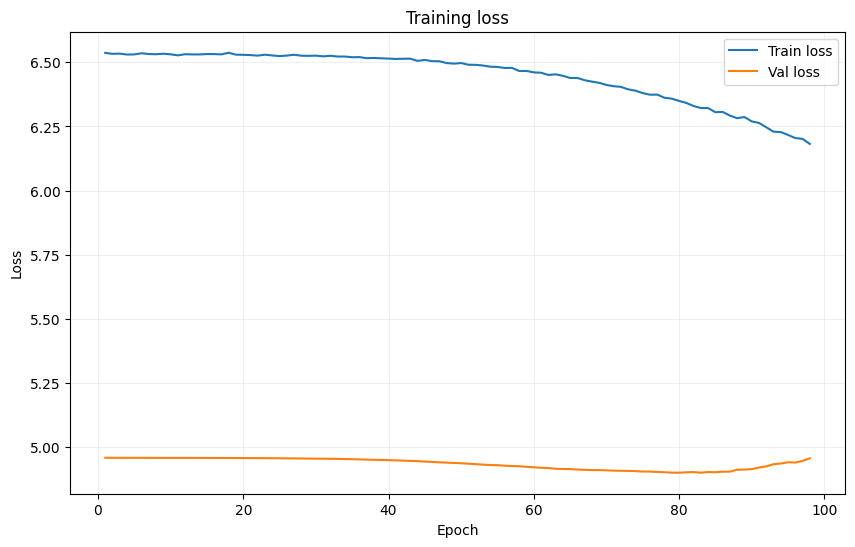

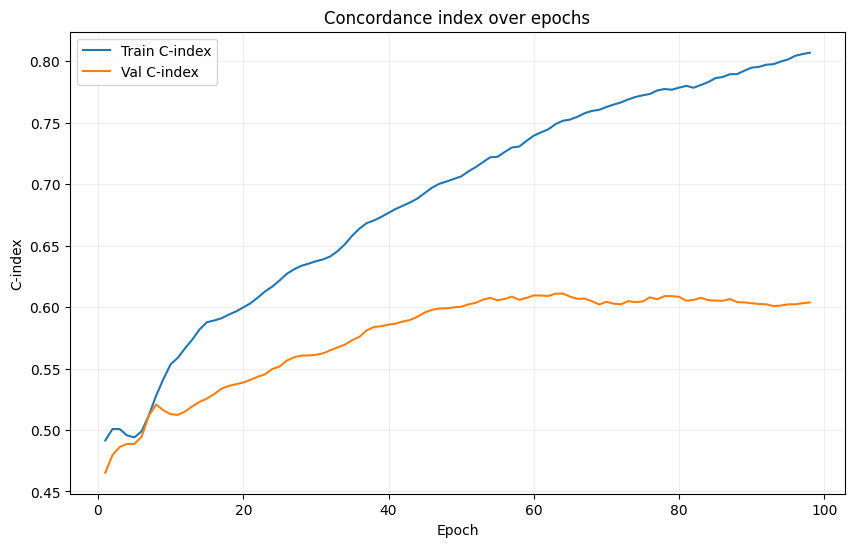

,epoch,train_loss,train_cindex,lr,val_loss,val_cindex,epoch_time_sec,elapsed_time_min
93,94,6.228093,0.799661,0.0005,4.936162,0.601179,0.279362,0.463296
94,95,6.216905,0.801411,0.0005,4.940958,0.602168,0.287527,0.468088
95,96,6.204812,0.804317,0.0005,4.940063,0.602233,0.282161,0.472791
96,97,6.201504,0.805771,0.0005,4.946409,0.603090,0.284744,0.477536
97,98,6.181930,0.806849,0.0005,4.956437,0.603683,0.286334,0.482309


In [ ]:

# =========================
# 16. Plot training history
# =========================
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
if "val_loss" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/AttentionDeepSurv/plot_TrainingLoss500.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_cindex"], label="Train C-index")
if "val_cindex" in history_df.columns:
    plt.plot(history_df["epoch"], history_df["val_cindex"], label="Val C-index")
plt.xlabel("Epoch")
plt.ylabel("C-index")
plt.title("Concordance index over epochs")
plt.legend()
plt.grid(True, alpha=0.2)
plt.savefig("/content/drive/MyDrive/ECEN766final/AttentionDeepSurv/plot_Cindex_over_epochs500.png", dpi=300)
plt.show()

history_df.tail()


In [ ]:

# =========================
# 17. Final evaluation
# =========================
train_ci = evaluate_cindex(model, train_data, scaler=scaler, device=DEVICE)
val_ci = evaluate_cindex(model, val_data, scaler=scaler, device=DEVICE)

print(f"Final Train C-index: {train_ci:.4f}")
print(f"Final Val   C-index: {val_ci:.4f}")

if test_data is not None:
    test_ci = evaluate_cindex(model, test_data, scaler=scaler, device=DEVICE)
    print(f"Final Test  C-index: {test_ci:.4f}")


Final Train C-index: 0.7806
Final Val   C-index: 0.6075
Final Test  C-index: 0.6107


In [ ]:

# =========================
# 18. Save model, scaler, history, feature names, and attention summaries
# =========================

OUTPUT_DIR = "/content/drive/MyDrive/ECEN766final/AttentionDeepSurv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model_path = os.path.join(OUTPUT_DIR, "attention_deepsurv_model.pt")
history_path = os.path.join(OUTPUT_DIR, "attention_deepsurv_training_history.csv")
feature_names_path = os.path.join(OUTPUT_DIR, "attention_deepsurv_feature_names.txt")
scaler_path = os.path.join(OUTPUT_DIR, "attention_deepsurv_scaler.npz")
config_path = os.path.join(OUTPUT_DIR, "attention_deepsurv_config.json")

attention_summary_path = os.path.join(OUTPUT_DIR, "attention_summary.csv")
top_genes_path = os.path.join(OUTPUT_DIR, "top_attended_genes.csv")


# Save model weights
torch.save(model.state_dict(), model_path)

# Save history
history_df.to_csv(history_path, index=False)

# Save feature names
with open(feature_names_path, "w") as f:
    for name in feature_names:
        f.write(f"{name}\n")

# Save scaler
if scaler is not None:
    np.savez(
        scaler_path,
        mean=scaler.mean.detach().cpu().numpy(),
        std=scaler.std.detach().cpu().numpy(),
    )

# Save config
config_to_save = {
    "model_class": model.__class__.__name__,
    "n_features": N_FEATURES,
    "d_model": 8,
    "n_heads": 1,
    "n_attn_layers": 1,
    "hidden_layers_sizes": [32],
    "dropout": 0.4,
    "use_feature_pooling": True,
    "standardize": STANDARDIZE,
}
with open(config_path, "w") as f:
    json.dump(config_to_save, f, indent=2)


# Compute and save attention summaries
model.eval()

x_all = torch.tensor(train_data["x"], dtype=torch.float32, device=DEVICE)

if scaler is not None:
    x_all = scaler.transform(x_all)

with torch.no_grad():
    log_risk, attn_maps = model(x_all, return_attention=True)

# attn_maps is a list, one entry per attention layer
# each item usually has shape:
#   [batch, num_heads, n_features, n_features]
# or sometimes [batch, n_features, n_features] depending on PyTorch settings

attention_rows = []
top_gene_rows = []

for layer_idx, attn in enumerate(attn_maps):
    attn_np = attn.detach().cpu().numpy()

    if attn_np.ndim == 4:
        # shape: [B, H, P, P]
        # average over patients and source positions
        # resulting shape: [H, P]
        mean_importance = attn_np.mean(axis=(0, 2))

        for head_idx in range(mean_importance.shape[0]):
            gene_scores = mean_importance[head_idx]  # [P]

            # full summary for this layer/head
            for gene_name, score in zip(feature_names, gene_scores):
                attention_rows.append({
                    "layer": layer_idx,
                    "head": head_idx,
                    "gene": gene_name,
                    "mean_attention_score": float(score),
                })

            # top 20 genes for this layer/head
            top_idx = np.argsort(gene_scores)[::-1][:20]
            for rank, idx in enumerate(top_idx, start=1):
                top_gene_rows.append({
                    "layer": layer_idx,
                    "head": head_idx,
                    "rank": rank,
                    "gene": feature_names[idx],
                    "mean_attention_score": float(gene_scores[idx]),
                })

    elif attn_np.ndim == 3:
        # shape: [B, P, P]
        # no explicit head dimension
        gene_scores = attn_np.mean(axis=(0, 1))  # [P]

        for gene_name, score in zip(feature_names, gene_scores):
            attention_rows.append({
                "layer": layer_idx,
                "head": 0,
                "gene": gene_name,
                "mean_attention_score": float(score),
            })

        top_idx = np.argsort(gene_scores)[::-1][:20]
        for rank, idx in enumerate(top_idx, start=1):
            top_gene_rows.append({
                "layer": layer_idx,
                "head": 0,
                "rank": rank,
                "gene": feature_names[idx],
                "mean_attention_score": float(gene_scores[idx]),
            })

attention_summary_df = pd.DataFrame(attention_rows)
top_genes_df = pd.DataFrame(top_gene_rows)

attention_summary_df.to_csv(attention_summary_path, index=False)
top_genes_df.to_csv(top_genes_path, index=False)


# Print summary
print("Saved model to:", model_path)
print("Saved history to:", history_path)
print("Saved feature names to:", feature_names_path)
print("Saved config to:", config_path)
print("Saved attention summary to:", attention_summary_path)
print("Saved top attended genes to:", top_genes_path)

if scaler is not None:
    print("Saved scaler to:", scaler_path)
else:
    print("No notebook scaler saved because STANDARDIZE=False.")

Saved model to: /content/drive/MyDrive/ECEN766final/AttentionDeepSurv/attention_deepsurv_model.pt
Saved history to: /content/drive/MyDrive/ECEN766final/AttentionDeepSurv/attention_deepsurv_training_history.csv
Saved feature names to: /content/drive/MyDrive/ECEN766final/AttentionDeepSurv/attention_deepsurv_feature_names.txt
Saved config to: /content/drive/MyDrive/ECEN766final/AttentionDeepSurv/attention_deepsurv_config.json
Saved attention summary to: /content/drive/MyDrive/ECEN766final/AttentionDeepSurv/attention_summary.csv
Saved top attended genes to: /content/drive/MyDrive/ECEN766final/AttentionDeepSurv/top_attended_genes.csv
No notebook scaler saved because STANDARDIZE=False.
